**Réalisation d’un système de prédiction d’un risque d'une classe de diabète.**

In [ ]:
pip install pandas

In [ ]:
pip install numpy

In [ ]:
pip install seaborn

In [ ]:
pip install matplotlib

In [ ]:
pip install ipywidgets

**Importation des outils nécessaires**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from sklearn.preprocessing import MinMaxScaler #Fonction de normalisation de données
from sklearn.preprocessing import StandardScaler#Fonction de standarisation de données
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV #chercher les meilleurs hyper parametre pour nos algorithmes
from sklearn.metrics import classification_report #tableau qui stocke les métriques de performance
from sklearn.feature_selection import RFE #réduit la dimensionnalité de notre jeu de données tout en préservant les performances des algorithmes

**Importation des données**

In [ ]:
df = pd.read_csv('/content/Dataset of Diabetes.csv')
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


Information sur l'ensemble des données

In [ ]:
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [ ]:
len(df[df['CLASS'] == 'N']) #0
df[df['CLASS'] == 'N']

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,181,454316,F,50,3.3,70,4.9,3.7,0.9,1.2,2.7,0.6,24.0,N
98,182,454316,M,60,7.5,70,0.9,3.4,5.3,1.1,3.6,0.8,24.0,N
99,186,454316,M,77,5.0,106,5.4,0.0,2.8,0.8,1.8,0.7,19.0,N
100,190,454316,F,59,4.7,58,4.1,4.5,1.8,1.8,1.8,1.3,22.5,N


In [ ]:
len(df[df['CLASS'] == 'Y']) #2

840

In [ ]:
len(df[df['CLASS'] == 'P']) #1
df[df['CLASS'] == 'P']

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
103,472,463,M,34,3.9,81,6.0,6.2,3.9,0.80,1.90,1.8,23.0,P
104,85,46300,M,34,3.9,81,6.0,6.2,3.9,0.80,3.80,1.8,23.0,P
105,710,87671,M,34,3.9,81,6.0,6.2,3.9,0.80,3.80,1.8,23.0,P
106,429,48036,M,31,3.4,55,5.7,4.9,1.6,1.00,3.20,0.7,24.0,P
107,702,87667,M,31,3.4,55,5.7,4.9,1.6,1.00,3.20,0.7,24.0,P
108,4,34301,F,43,2.1,55,5.7,4.7,5.3,0.90,1.70,2.4,25.0,P
109,189,30383,M,42,5.4,53,5.8,5.9,3.7,1.30,3.10,1.7,23.0,P
110,201,45573,M,47,4.1,87,6.2,3.7,1.8,1.00,2.00,0.8,23.0,P
111,285,47069,M,50,4.3,59,6.1,4.0,3.0,1.00,1.80,1.3,24.0,P
112,393,47496,M,49,5.0,74,6.2,2.0,0.8,0.60,1.00,0.4,25.0,P


**Remarque** :
Nous remarquons que la majorité des patients sont positif.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [ ]:
pd.isnull(df).sum()

,0
ID,0
No_Pation,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0


Apparemment il n'ya pas de valeurs manquantes. Mais les valeurs manquantes peuvent etre cachées. L'analyse exploiratoire des données nous donnera beaucoup plus d'information sur les données  

In [ ]:
# Nombre de valeur uniques par colone
df.nunique()

,0
ID,800
No_Pation,961
Gender,3
AGE,50
Urea,110
Cr,113
HbA1c,111
Chol,77
TG,69
HDL,48


**1. Analyse exploratoire des données** *texte en italique*

Commencons notre analyse en tracant un graphique de visualisation de la distribution de chaque variable .

**Variables catégorielles**

In [ ]:
# Nous remarquons que nos variable catégorielle sont les variables qui ont moins de six modalité distinct ce qui n'est pas normale essayons de les lister de facon distinct pour oir le probléme
catégorical_columns = df.nunique()[df.nunique() < 6].keys().to_list()
catégorical_columns
for n in catégorical_columns:
  print(n)
  print(df[n].unique())

Gender
['F' 'M' 'f']
CLASS
['N' 'N ' 'P' 'Y' 'Y ']


Nous remarquons que notre jeux de données contient deux variables catégorielle (Gender et CLASS) mais des redondances de valeurs existent au niveau de leur enregistrement .

1) Nettoyage des erreurs d'enregistrement pour les variables catégorielle:

In [ ]:
for i in catégorical_columns:
  df[i] = df[i].str.replace(" ", "", n = 1)
  df[i]= df[i].str.upper()
  print(i)
  print(df[i].unique())

Gender
['F' 'M']
CLASS
['N' 'P' 'Y']


In [ ]:
# Fonction à barre des variables catégorielles
def bar_plot(a):
  df[a].value_counts(normalize= True).plot(kind= 'bar')
  plt.ylabel('proportion')
  plt.title('Distribution of'  + ''+ str(a))
  return plt.show()

In [ ]:
#Affichage interactif des graphes
interact(bar_plot, a = catégorical_columns )

interactive(children=(Dropdown(description='a', options=('Gender', 'CLASS'), value='Gender'), Output()), _dom_…

<function __main__.bar_plot(a)>

Conclusion

---


1.   Pour la variable cible nous avons remarqué un proléme de
     désiquilibrage de la catégorie des patients de classe diabétique plus de 80%  par rapport aux classes  non diabétique moins de 12% et diabétique prédit moins de 6% .
2.   Pour la variable catégorielle gender nous remarqons aussi un
     désiquilibrage au niveau de la distribution les males représentant plus de 60% que les femelles. Et cela peut impacter négativement la performance des modéles de classification que nous allons construire .



**Variables quantitatif**

In [ ]:
# Nous remarquons que nos variable quantitatif sont les variables qui ont plus de trois modalité distinct
numérical_columns = df.nunique()[df.nunique() > 3].keys().to_list()
numérical_columns
#Echantillonnemennt aléatoire
#df['ID'].sample(10)
#CONVERSION en cas probléme type
#df['ID'] = df['ID'].replace('' , np.nan).astype(float)

['ID',
 'No_Pation',
 'AGE',
 'Urea',
 'Cr',
 'HbA1c',
 'Chol',
 'TG',
 'HDL',
 'LDL',
 'VLDL',
 'BMI']

In [ ]:
# Coéficsicent d'asymétrie des variable quantitatif
for i in numérical_columns:
  print(i)
  print(df[i].skew())

ID
0.33267921198462375
No_Pation
19.56102868778898
AGE
-0.8195359020100546
Urea
4.298927889976489
Cr
8.47415115621381
HbA1c
0.22168940098610398
Chol
0.6171226608860232
TG
2.298456097830948
HDL
6.283201244977265
LDL
1.1459095882506958
VLDL
5.350444676831296
BMI
0.12580693961045922


Nous remarquons que certaines de nos  variables quantitatif ont un coéficient  d'asymétrie <0 leurs distributions seront  étalée à gauche de la moyenne et d'autres ont un coéficient  d'asymétrie >0 leurs distributions seront  étalée à droite de la moyenne .

- La variable age a un coéficient <0 rasison pour laquelle sa distribution
  est étalée à gauche de la moyenne (voir figure ci-dessous )

- Tant disque certain  variables  quantitatif ont un coéficient >0 et son
  trop loin de 0 raison pour laquelle ses variables concerné sont trop assymétrie ce qui fait que leurs distributions sont étalée à droite de la moyenne (voir figure ci-dessous ). Nous allons utiliser des méthodes de transformation pour La transformer et la rendre beaucoup plus symétrique.Nous allons élaborer cette étape dans la phase de prétraitement .

In [ ]:
# Fonction à barre de chacune de ses variables quantitatif
def hist_plot(b):
  sns.displot(df[b], kde=False)

  df[b].value_counts(normalize= True).plot(kind= 'bar')
  plt.title('Histogram of' +''+ str(b))
  return plt.show()
#Affichage interactif des graphes
interact(hist_plot, b = numérical_columns)

interactive(children=(Dropdown(description='b', options=('ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Cho…

<function __main__.hist_plot(b)>

**Boite à moustache pour détecter les valeurs aberrante**

In [ ]:
# Création d'une fonction de construction de boites à moustaches et de maniére interactive
def box_plot(b):
  sns.boxplot(y = df[b])
  plt.title('Boxplot of' +''+ str(b))
  return plt.show()
  #Affichage interactif des graphes
interact(box_plot, b = numérical_columns)

interactive(children=(Dropdown(description='b', options=('ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Cho…

<function __main__.box_plot(b)>

Conclusion

---

1.   Nous remarquons des valeurs aberantes  aux extrémité des boxs de
     certaines variables quantitatif.
     Et cela peut impacter négativement la performance des modéles de
     classification que nous allons construire .

2.   Nous devons aussi appliquer des fonctions de
     transformation à ces variables afin de les rendres moins asymétrique.

     Conclusion:  

---
Nous venons de faire une analyse univarié pour comprendre chaque variable dans la suite nous allons procéder a l'analyse bi-varié pour identifié les corrélations qui existe entre les variable d'entrée et la variable de sortie . Comme un bon modéle est unn modéle concu avec des variables d'entrée en forte corrélation avec la variable de sortie .



     

In [ ]:
#Analyse bivarié pour vérifié les corrélances et accointance entre les variables
numérical_columns

['ID',
 'No_Pation',
 'AGE',
 'Urea',
 'Cr',
 'HbA1c',
 'Chol',
 'TG',
 'HDL',
 'LDL',
 'VLDL',
 'BMI']

In [ ]:
numérical_columns=np.delete(numérical_columns,0)
numérical_columns=np.delete(numérical_columns,0)
numérical_columns

array(['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL',
       'BMI'], dtype='<U9')

5


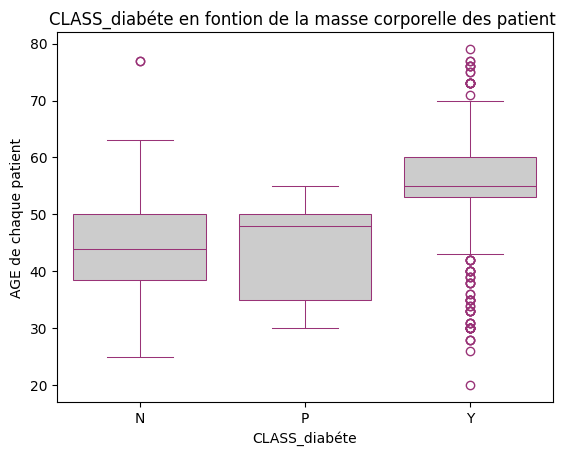

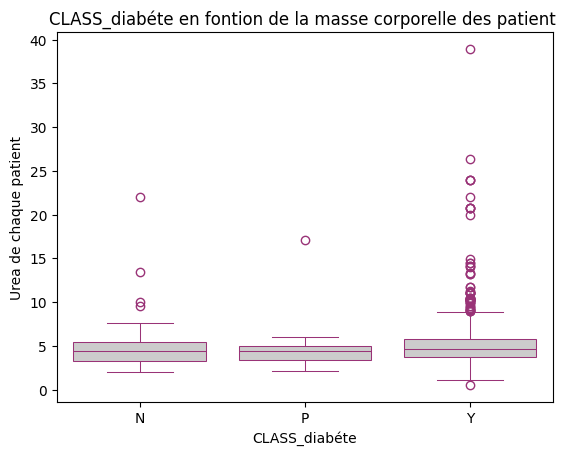

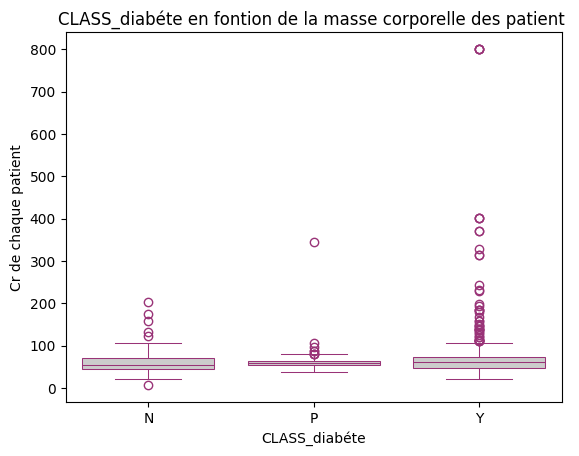

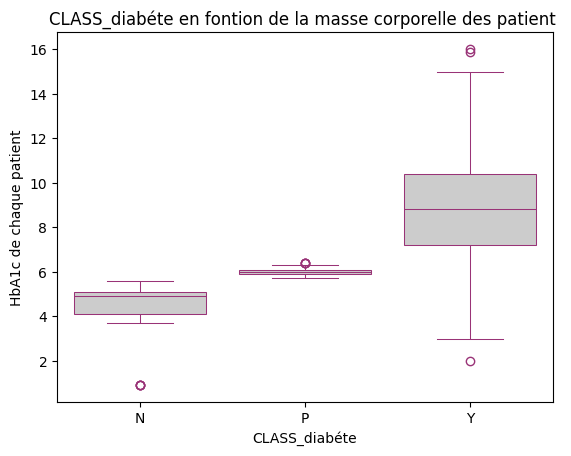

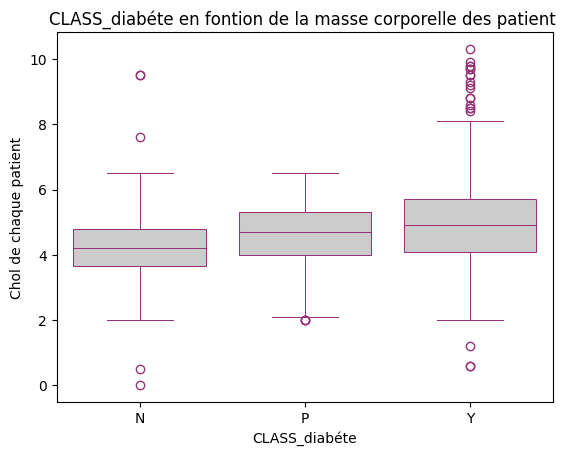

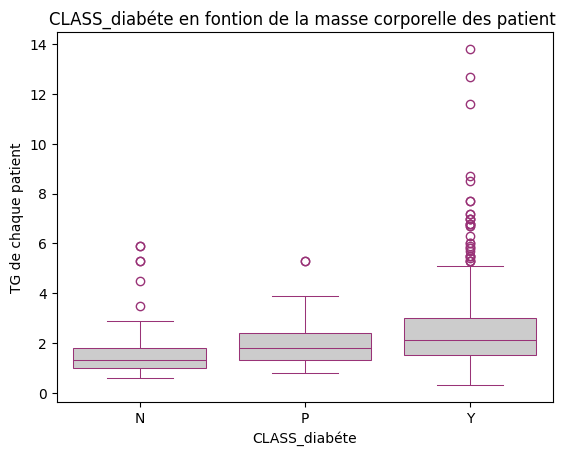

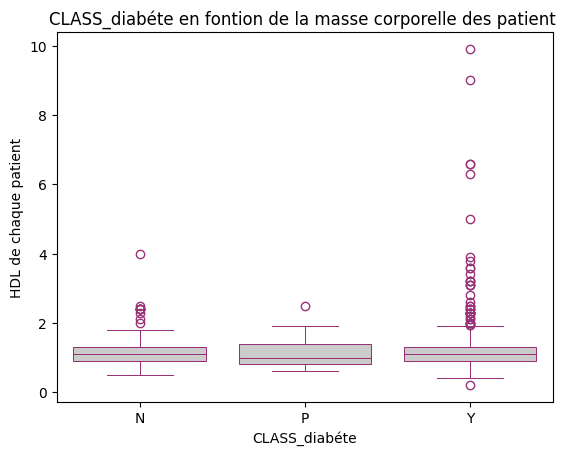

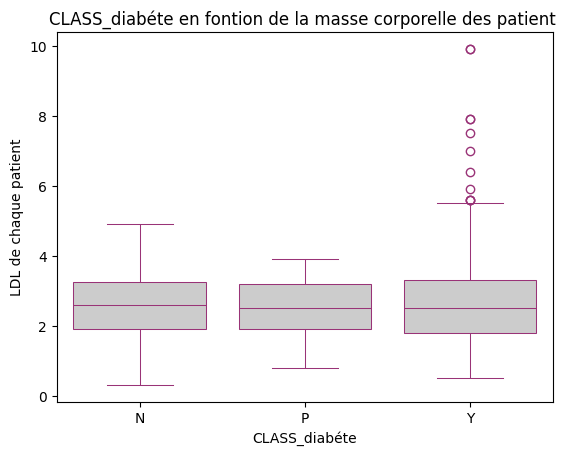

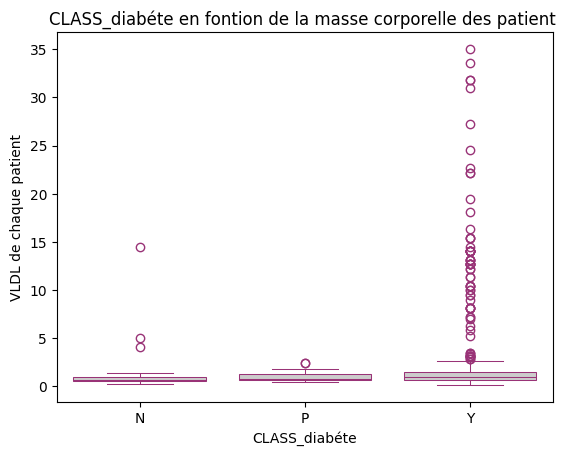

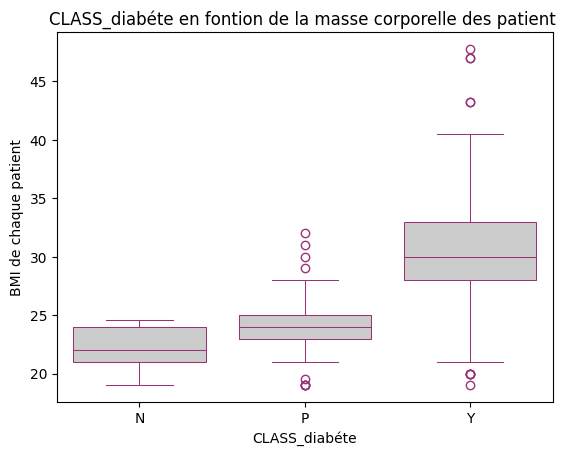

In [ ]:
L= len(numérical_columns)
L=int(L/2)
print(L)
for i in numérical_columns:
  sns.boxplot(x='CLASS', y=str(i), data=df, color=".8", linecolor="#937", linewidth=.750 , )
  plt.xlabel('CLASS_diabéte')
  plt.ylabel( i+' de chaque patient')
  plt.title('CLASS_diabéte en fontion de la masse corporelle des patient ' )
  plt.show()
  print("")

Conclusion

---

# Analyse de l'âge en fonction de la classe diabète
Nous remarquons que les patients testé positif ont la plupart plus de 55ans et son plus minoritaire parmi les autres cas d'âges de  patient. Un nombre important de patient âgé en moyenne de 49ans risque d'avoir le diabète .Un nombre important de patient âgé en moyenne de 42 ans mais moins important que les patients âgé en moyenne de 50 ans sont testé négatif.

Ce qui montre que la variable âge joue un rôle important  pour la variable à prédire .



# Analyse de l'HbA1c en fonction de la classe diabète
Nous remarquons que plus le HbA1c est important plus le patient est ou proche d'être diabétique positif . Un nombre important de patient  tester positif ont en moyenne un HbA1c égale a 9. Peu de patient ayant un HbA1c en moyenne égale a 7 risque d'être positif. Un nombre important de patient mais moins important que ceux qui ont en moyenne un HbA1c égale à 9 et qui ont un HbA1c en moyenne égale a 5 sont testé négatif.

Ce qui montre que la variable HbA1c joue un rôle important pour la variable à prédire .


# Analyse du BMI en fonction de la classe diabète
Nous remarquons que plus le BMI est important plus le patient est ou proche d'être diabétique positif . Un nombre important de patient tester positif ont en moyenne un BMI égale a 31. Peu de patient ayant un BMI en moyenne égale a 23 risque d'être positif. Un nombre important de patient mais moins important que ceux qui ont en moyenne un BMI égale à 31 et qui ont un BMI en moyenne égale a 23 sont testé négatif.

Ce qui montre que la variable BMI joue un rôle important pour la variable à prédire .


In [ ]:
#Résumé statistique
df[numérical_columns].describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


Conclusion:

---



1.   Nous remarquons que nos variable sont a diférentes échelle tenant
     compte de leur max et de leur min . De nombreux modéle de machine learning fonctionne mieux avec des variable standariser ou normalisé donc ce qui nous indique que dans la partie prétraitement nous devons standariser ou normaliser nos données.


**CONCLUSION SUR L'anlayse exploratoire de données **

---



1.   Cette analyse exploratoire de nos données nous a permis de mieux les
     comprendres et d'avoir des indication sur le type de prétraitement que nous allons opéré avant de passer à la modelisation donc dans la suite du projet nous allons passer au prétraitement aux nettoyage de nos données.   



**1. Prétraitement  des données** *texte en italique*

In [ ]:
#Gestion de valeurs manquante
df2 = df.copy()
#df2.isna().sum()
#supression des données manquante
#df2.dropna(inplace=True)

En effet les algorithmes de machine learning ne prennent pas en entré des chaine de caractére ils ne reconnaissent que des données numérique. D'ou nous procédons à l'encodage des variables catégorielle dans la suite de notre projet .

In [ ]:
#Encodage des variable catégorielle en des variables binaires
#Nos variable catégorielle sont :
catégorical_columns
for n in catégorical_columns:
  print(n)
  print(df[n].unique())

Gender
['F' 'M']
CLASS
['N' 'P' 'Y']


In [ ]:
#Pour le cas de Gender avec encodage binaire
#df2['Gender'] = df2['Gender'].apply(lambda row: 1 if row == 'M' else 0)
#Prend dans le jeu de données uniquement les colones des variable qui ont moins de trois valeurs distincte
#binary_colums = df2.drop('Gender', axis =1).nunique()[data.drop('Gender', axis=1).nunique()<3].keys().to_list()
#for column in binary_colums:
#     df2[column] = df2[column].apply(lambda row: 1 if row == 'Yes' else 0)
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
enc.fit(df2[["Gender"]])
df2[["Gender"]] = enc.transform(df2[["Gender"]])
#df2.loc[df2["Gender"] == "M", "Gender"] = 1
#df2.loc[df2["Gender"] == "F", "Gender"] = 0
#Pour le cas de CLASS avec encodage a 3 catégirie
#df2.loc[df2["CLASS"] == "N", "CLASS"] = 0
#df2.loc[df2["CLASS"] == "P", "CLASS"] = 2
#df2.loc[df2["CLASS"] == "Y", "CLASS"] = 1
#remaining_cat_vars = df2[catégorical_columns].nunique()[df2[catégorical_columns].nunique()>2].keys().to_list()
#remaining_cat_vars_dumies = pd.get_dummies(df2=df2[remaining_cat_vars], columns=remaining_cat_vars,drop_first=True)

In [ ]:
#Nouvelle dataframe
#df_new=pd.concat([df2['Gender'], df2[binary_colums], remaining_cat_vars_dumies, df2[numérical_columns]], axis=1)
df2.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,0.0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,1.0,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,0.0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,0.0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,1.0,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
#Shape de data
df2.shape

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   float64
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(9), int64(4), object(1)
memory usage: 109.5+ KB


Les algorithmes de machine learning fonctionnent mieux dans des variables à disposition symétrique . Donc il est necessaire de transformer les variable assymétirique dont leur coéficient est trop loin de 0.
Dans les lignes qui suivent nous allons utilisé la fonction racine carré pour voir si cette fonction améliore la distribution des variables assymétrique.

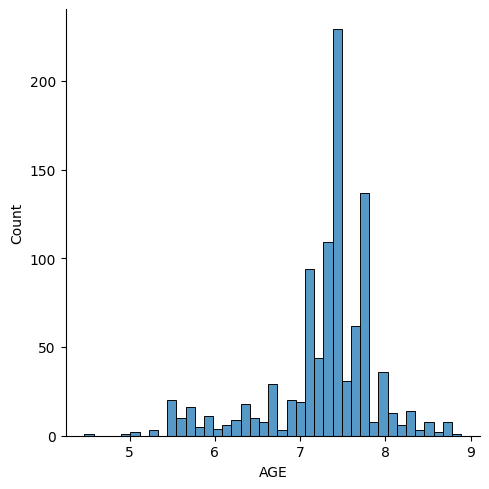

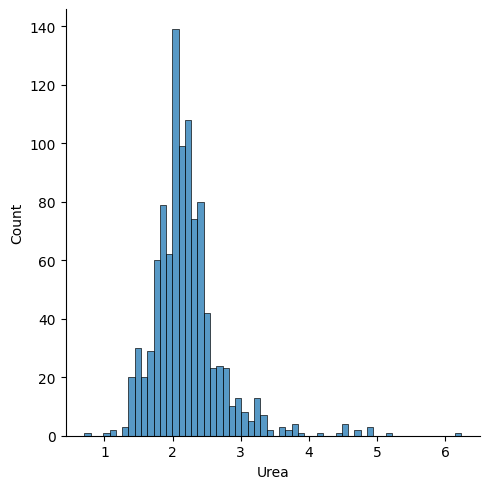

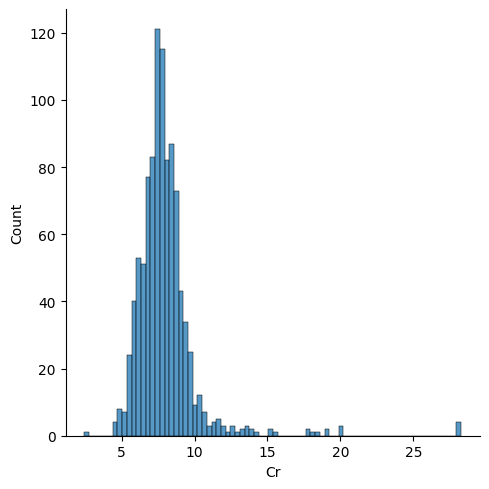

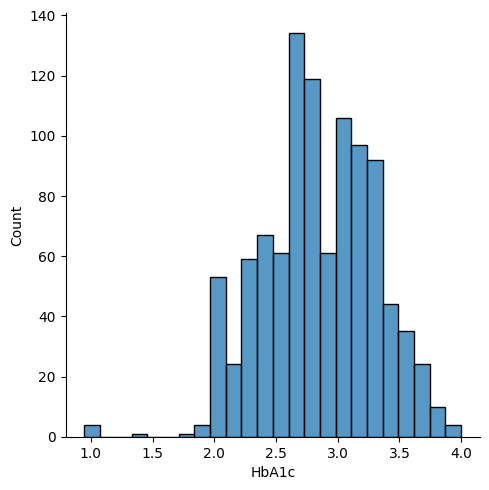

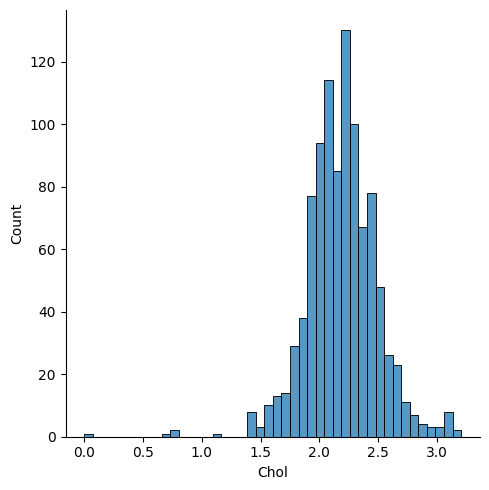

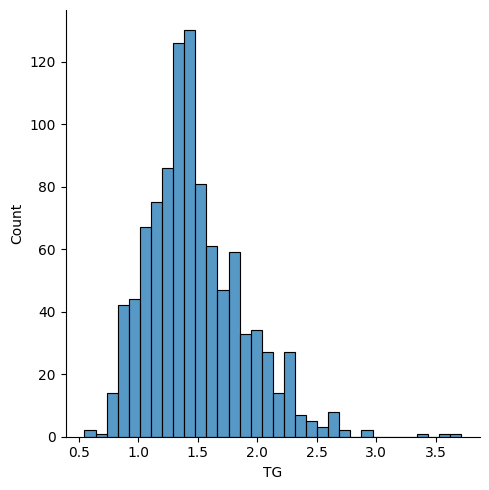

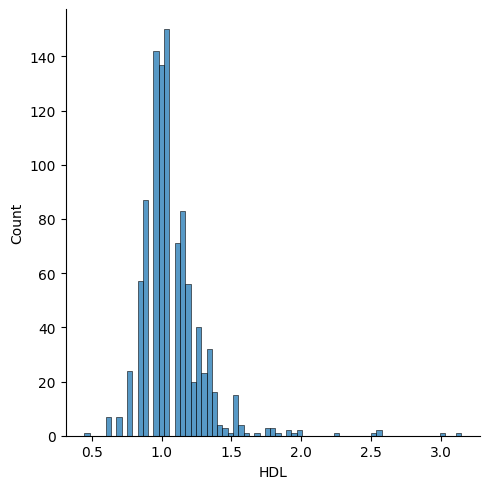

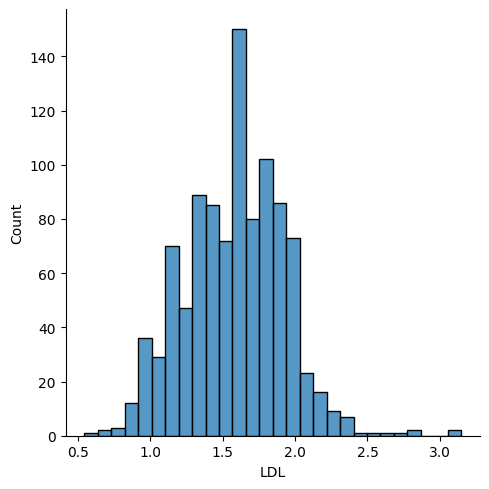

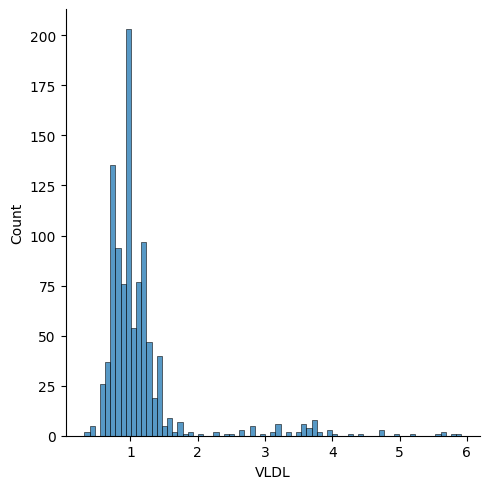

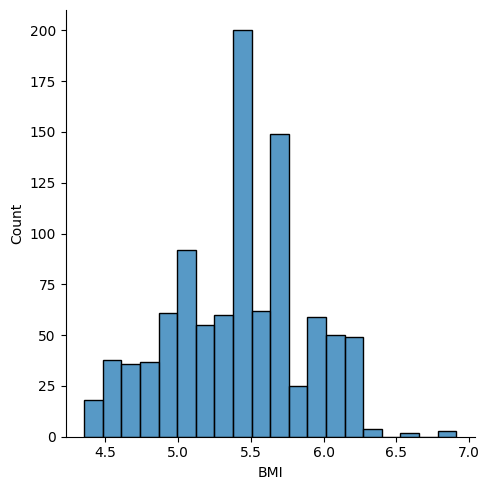

In [ ]:
#Transformation des variables asymétrique par par la fonction recine carré
for h in numérical_columns:
  df2[h] = np.sqrt(df2[h])
  #Histogramme de la variable transformée
  sns.displot(df2[h], kde=False)
  print("")
  print("")


Conclusion

---

Nous remaarquons que ces histogrammes se présentent mieux par rapport aux anciens . La symétrie n'est pas parfait mais a parfaitement améliorer. Essayons de calculer leurs coéfiscient d'asymétrie qui a servir de preuve

In [ ]:
# Coéficsicent dasymétrie des variable quantitatif
#for i in numérical_columns:
 # print(i)
  #print(df2[i].skew())

In [ ]:
#Détection et Supression des outliers
#Calcule des quartiles
for i in numérical_columns:
  print("Détection outliers pour la variable "+ i)
  Q1= df2[i].quantile(0.25)
  Q3= df2[i].quantile(0.75)
  IQR = Q3 -Q1
  coef = IQR* 1.5
  #Calcule des valeurs limite
  lim_inf = Q1 - coef
  lim_sup = Q3 + coef
  #Détection et affichage des outliers
  resultat = df2[(df2[i] > lim_sup) | (df2[i] < lim_inf)]
  #print("Détection et affichage des outliers dans un tableau")
  #print(resultat.sort_values(str(i)))
  #filtre des outliers
  df2 = df2[(df2[i] <= lim_sup) & (df2[i] >= lim_inf)]
  #print("affichage des résultats aprés Détection et supression des outliers ")
  w= df2[(df2[i] <= lim_sup) & (df2[i] >= lim_inf)]
  #print(w)
  print("Coéfisciant d'asymétrie aprés Détection et supression des outliers :")
  print(df2[i].skew())
  print("")
  print("")



Détection outliers pour la variable AGE
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
-0.27297970395043636


Détection outliers pour la variable Urea
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
0.1278582382627822


Détection outliers pour la variable Cr
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
-0.03470356763028243


Détection outliers pour la variable HbA1c
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
-0.11804966896041444


Détection outliers pour la variable Chol
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
-0.046569488666497995


Détection outliers pour la variable TG
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
0.36536363363683994


Détection outliers pour la variable HDL
Coéfisciant d'asymétrie aprés Détection et supression des outliers :
0.40343619203643644


Détection outliers pour la variable LDL
Coéfisciant d'asymétrie aprés Détecti

Conclusion

---



1.   Aprés Détection et supression des outliers nous remarqons avoir des
     variables a distribution symétrie avec des coéficient d'asymétri proche de 0.
2.   Éssayons de voir les résultats obtenu aux visuel.



In [ ]:
# Création d'une fonction de construction de boites à moustaches  de maniére interactive
def box_plot(b):
  sns.boxplot(y = df2[b])
  plt.title('Boxplot of' +''+ str(b))
  return plt.show()
  #Affichage interactif des graphes
interact(box_plot, b = numérical_columns)

interactive(children=(Dropdown(description='b', options=('AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'L…

<function __main__.box_plot(b)>

In [ ]:
# construction d'une Fonction à barre  de maniére interactive
def hist_plot(b):
  sns.displot(df2[b], kde=False)

  df[b].value_counts(normalize= True).plot(kind= 'bar')
  plt.title('Histogram of' +''+ str(b))
  return plt.show()
#Affichage interactif des graphes
interact(hist_plot, b = numérical_columns)

interactive(children=(Dropdown(description='b', options=('AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'L…

<function __main__.hist_plot(b)>

Visulisation des résultats dans un histogramme aprés Détection et supression des outliers












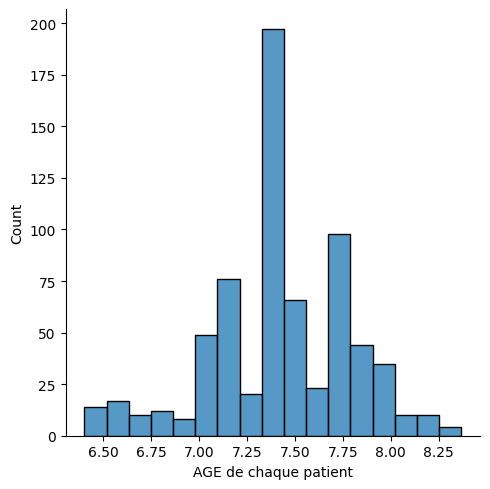

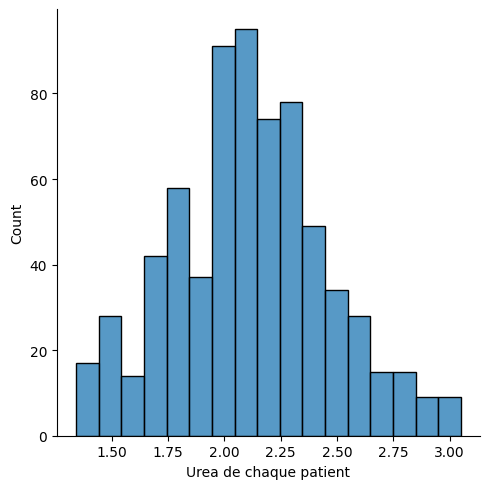

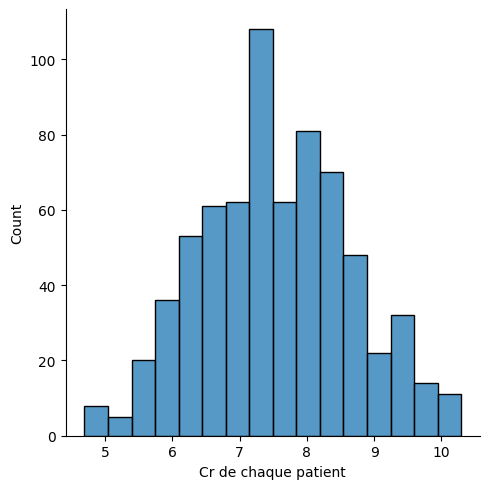

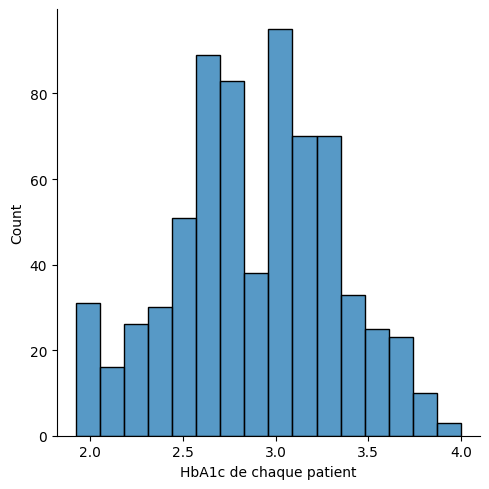

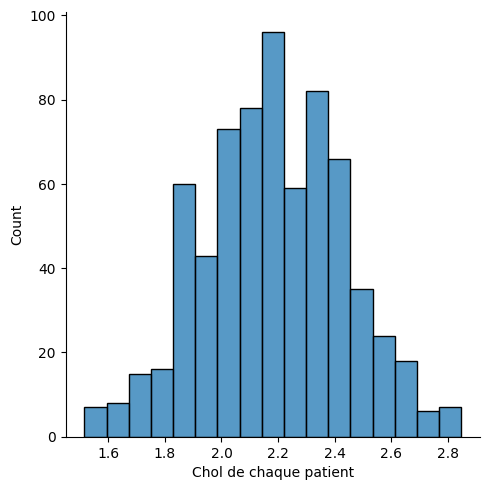

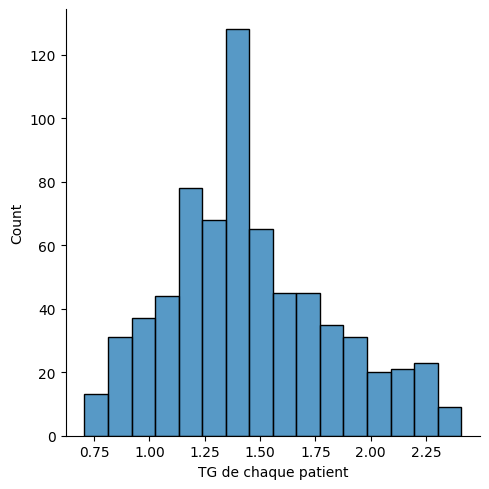

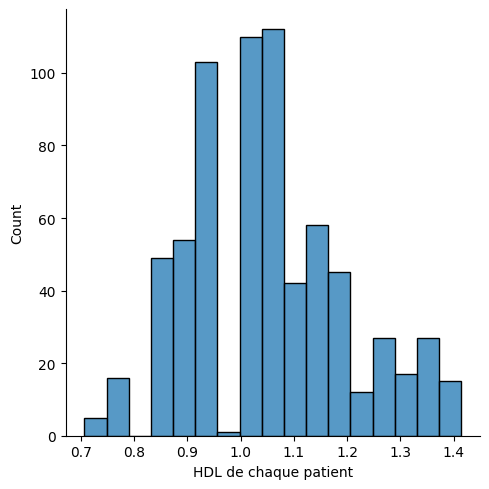

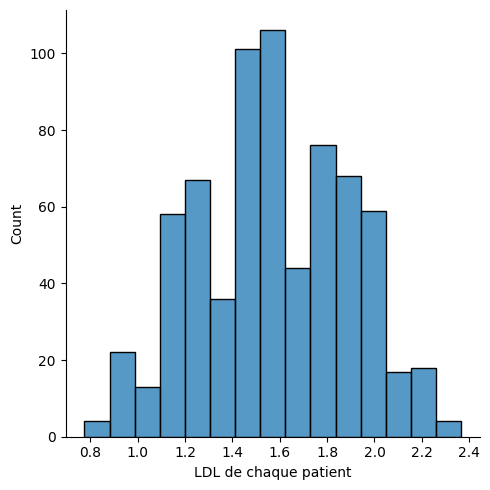

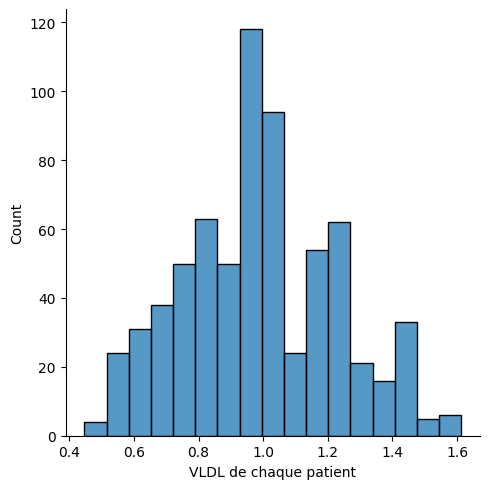

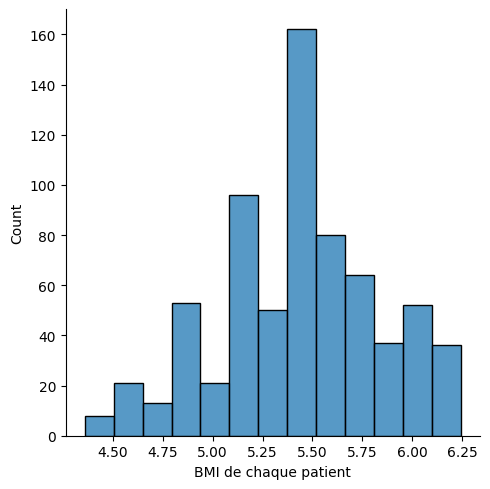

In [ ]:
print("Visulisation des résultats dans un histogramme aprés Détection et supression des outliers")
for i in numérical_columns:
  #df2[i].plot.hist(bins=20)
  # Vue des Histogrammes actuel pour voir la symétrie de la distribution des variables apres supressions des valeur aberrantes
  sns.displot(df2[i], kde=False)
  plt.xlabel(i+' de chaque patient')
  print("")

Conclusion

---



1.   Nous remaquons que nous n'avons plus de valeur abérantes et la
     disposition des variables est devenu symétrie.  
2.   Mais n'empéche dans les graphes ci-dessus nous remarquons une grande différence au niveau de certaines valeurs des variables ceci peut impacter négativement sur le modéle a contruire . Raison pour laquelles des opérations de normalisation et de vectorisation doivent etre éffectuer au niveau de ses variables pour remédier a ce probléme .



**3. Phase de séparation des données en données
d'entrainement de validation et de test**

---
Les données d'entrainement c'est pour entrainer le modéle .
Les données de validation  c'est pour sélectionner le meilleurs modéle parceque nous allons utiliser plusieurs algorithmes, ces derniers seront entrainer a partir des données d'entrainement et formeront des modéles. Il faudra selectionner le meilleurs modéle parmi tous ses modéles construit et ce sont les performances sur les données de validation qui vont nous permettre de selectionner ce meilleurs modéle et pour finir ce meilleur modéle sera évaluer sur les données de test afin de vouloir vraiment s'assurer de la capacité du modéle à généraliser donc il s'agit d'une double vérification ou double sécurité .  


In [ ]:
#Données d'entrainement (60%), de validation (20%) et de test (20%)
df2.drop(['ID', 'No_Pation'], axis=1, inplace=True)
df2

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0.0,6.708204,1.516575,4.898979,2.000000,1.702939,1.000000,1.000000,1.224745,0.632456,4.582576,N
6,0.0,7.071068,1.414214,7.071068,2.000000,1.897367,1.140175,0.948683,1.449138,0.774597,4.898979,N
7,1.0,6.928203,2.167948,6.855655,2.000000,1.702939,0.894427,0.948683,1.264911,0.632456,4.898979,N
13,0.0,6.708204,2.144761,7.348469,2.258318,2.049390,1.303840,1.095445,1.483240,0.894427,4.795832,N
14,0.0,7.071068,1.870829,6.244998,2.000000,2.000000,1.224745,1.095445,1.483240,0.836660,4.898979,N
...,...,...,...,...,...,...,...,...,...,...,...,...
989,1.0,7.874008,2.509980,9.055385,2.588436,2.302173,1.414214,1.000000,1.870829,0.948683,5.486347,Y
990,0.0,7.549834,2.024846,8.366600,3.049590,2.302173,1.816590,1.000000,1.183216,1.140175,5.385165,Y
991,0.0,7.416198,2.024846,5.830952,3.728270,2.323790,1.264911,1.264911,1.760682,0.836660,5.744563,Y
992,1.0,7.416198,1.760682,6.244998,2.915476,2.236068,1.581139,1.378405,1.702939,0.836660,5.196152,Y


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 693 entries, 5 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  693 non-null    float64
 1   AGE     693 non-null    float64
 2   Urea    693 non-null    float64
 3   Cr      693 non-null    float64
 4   HbA1c   693 non-null    float64
 5   Chol    693 non-null    float64
 6   TG      693 non-null    float64
 7   HDL     693 non-null    float64
 8   LDL     693 non-null    float64
 9   VLDL    693 non-null    float64
 10  BMI     693 non-null    float64
 11  CLASS   693 non-null    object 
dtypes: float64(11), object(1)
memory usage: 70.4+ KB


- Division en données d'entrainement et de test du jeux de données obtenue aprés prétraitement .:

In [ ]:
X = df2.drop('CLASS', axis= 1)
Y = df2['CLASS']
from sklearn import preprocessing
from sklearn import utils
lab_enc = preprocessing.LabelEncoder()
encoded = lab_enc.fit_transform(Y)
print(utils.multiclass.type_of_target(Y))
print(utils.multiclass.type_of_target(Y.astype('str')))
print(utils.multiclass.type_of_target(encoded))
Y = encoded
print(df2['CLASS'])
print(Y)
seed = 1111
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state= seed, stratify= Y)

multiclass
multiclass
multiclass
5      N
6      N
7      N
13     N
14     N
      ..
989    Y
990    Y
991    Y
992    Y
999    Y
Name: CLASS, Length: 693, dtype: object
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 



1.   train_test_split est une fonction qui joue le role de divison du jeu de données .
2.   LA variable seed est utiliser pour s'assurer de la reproductivité des résultats parceque la fonction train_test_split fait la disvsion des données de maniére aléatoire pour s'assurer qu'a chaque nouvelle execution qu'on garde la méme divsion la variable seed est important.
3. La variable stratify permet de conserver le méme proportion obtenue avant et aprés division des données de la variable cible. La fonction tran_test_split fait ca division de maniére aléatoire jusqu'a changer a chaque nouvelle exécution les proportions d'avant de nos variable donc les variables seed et stratify sont la pour remédier à ca .



- Division en données de validation  et de test des variables test obtenu apres la division du jeux de données obtenue aprés prétraitement mais en deux partie égale donc test_size=0.5 .



In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 693 entries, 5 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  693 non-null    float64
 1   AGE     693 non-null    float64
 2   Urea    693 non-null    float64
 3   Cr      693 non-null    float64
 4   HbA1c   693 non-null    float64
 5   Chol    693 non-null    float64
 6   TG      693 non-null    float64
 7   HDL     693 non-null    float64
 8   LDL     693 non-null    float64
 9   VLDL    693 non-null    float64
 10  BMI     693 non-null    float64
 11  CLASS   693 non-null    object 
dtypes: float64(11), object(1)
memory usage: 70.4+ KB


In [ ]:
seed = 1111
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state= seed, stratify= Y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state= seed, stratify= y_test)

Conclusion

---


Finale j'aurai 60% de données attester au données d'entrainement , 40% etait attribuer au donner de test mais arrivé dans la partie de validation ce derniers est divisé en deux partie dont 20% seront maintenant attribuer aux données de test et les 20% qui reste au données de validation .

Cette validation  sert a valider notre modéle sur des données qu'il na jamais afin de sasurer sur ses performance a pourvoir faire de l'apprentissage sur des données futur .

Verification de la conservation des proprotions des données obtenu au niveau de la Variable cible avant et apres l'utilisation de la fonction train_test_split.

In [ ]:
#Fréquence des classes dans Y avant utilisation de la variable stratify
pd.DataFrame(Y).value_counts(normalize= True)

,proportion
0,
2,0.887464
0,0.074074
1,0.038462


Fréquence des classes dans y aprés un train_test_split des données.

In [ ]:
#Pour le y_train des données d'entrainement
pd.DataFrame(y_train).value_counts(normalize= True)

,proportion
0,
2,0.888361
0,0.073634
1,0.038005


In [ ]:
#Pour le y_test des données de test
pd.DataFrame(y_test).value_counts(normalize= True)

,proportion
0,
2,0.886525
0,0.078014
1,0.035461


In [ ]:
#Pour le y_val des données de validation
pd.DataFrame(y_val).value_counts(normalize= True)

,proportion
0,
2,0.885714
0,0.071429
1,0.042857


Conclusion

---

Nous remarquons belle et bien une conservation des proportions de la variable aprés chaque utilisation de la fonction train_test_split

Comme dans la partie exploration des données nous avions remarqué une  grande différence au niveau de certaines valeurs des variables ceci peut impacter négativement sur le modéle a contruire . Raison pour laquelles des opérations de normalisation et de vectorisation doivent etre éffectuer au niveau de ses variables pour remédier a ce probléme .

Dans les lignes qui suivantes nous allons attaqué la partie normalisation ou standarisation

**Probléme de désiquilibre de données **

```



Lorsqu'il ya une grande différence entre le nombre d'observation dans chaque catégorie de la variable a prédire cela peut entrainer des érreurs de modélisation.

Dans notre cas ici, il ya 80% de patient testé positif, a peu prés 7% de patient prédit positif et à peu prés 4% Tester négatif. Donc il ya un grand nombre de désquilibre de classe . Nous pouvons utiliser le rééchantionnage pour créer plus d'équilibre entre les catégories de la variable cible. Soit on crée plus d'observations dans la classe minoritaire(modalité 1) c'est à dire on fait un sur-échantillonange, soit on diminue les observations de la classe majoritaire ( modalité 0) c'est-à-dire un sous échantillonage.

Dans les lignes qui suivre nous allons utiliser toutes les deux méthodes et prendre la meilleure.

In [ ]:
#Résolution du probléme de désiquilibre de classe : Methode de sur-échantillonage de la minoritaire
X2 = X_train
X2['CLASS'] = y_train
minority = X2[X2.CLASS == 0]
minority1 = X2[X2.CLASS == 1]
majority = X2[X2.CLASS == 2]
minority_upsampled = resample(minority, replace= True, n_samples=len(majority), random_state=seed)
minority1_upsampled = resample(minority1, replace= True, n_samples=len(majority), random_state=seed)
upsampled = pd.concat([majority, minority1_upsampled, minority_upsampled])


In [ ]:
#Vérification
upsampled['CLASS'].value_counts(normalize=True)

,proportion
CLASS,
2,0.333333
1,0.333333
0,0.333333


In [ ]:
#Données d'entrainement sur la base de sur-échantillonge de la classe minoritaire
X_train_up = upsampled.drop('CLASS', axis= 1)
y_train_up = upsampled['CLASS']

In [ ]:
#Résolution du probléme de désiquilibre de classe : Methode de sous-échantillonage de la majoritaire
X2 = X_train
X2['CLASS'] = y_train
minority = X2[X2.CLASS == 0]
minority1 = X2[X2.CLASS == 1]
majority = X2[X2.CLASS == 2]

majority_downsampled = resample(majority, replace= False, n_samples=len(minority1), random_state=seed)
majority1_downsampled = resample(minority, replace= False, n_samples=len(minority1), random_state=seed)
downsampled = pd.concat([minority1, majority_downsampled, majority1_downsampled])


In [ ]:
#Vérification
downsampled['CLASS'].value_counts(normalize=True)

,proportion
CLASS,
1,0.333333
2,0.333333
0,0.333333


In [ ]:
#Données d'entrainement sur la base de sous-échantillonge de la classe majoritaire
X_train_down = downsampled.drop('CLASS', axis= 1)
y_train_down = downsampled['CLASS']

In [ ]:
#y_train et X_train
y_train = X_train['CLASS']
X_train = X_train.drop('CLASS', axis=1)
X_train

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
395,0.0,2.710806,1.440015,2.575510,1.660364,1.524398,1.189207,1.000000,1.367782,0.974004,2.285813
405,1.0,2.783158,1.545143,2.952592,1.614832,1.531407,1.106682,0.914691,1.422971,0.914691,2.396782
767,1.0,2.817313,1.367782,2.710806,1.782709,1.558522,1.326907,1.024114,1.269823,1.087757,2.300327
541,1.0,2.783158,1.203801,2.735565,1.660364,1.347809,1.141858,0.974004,1.141858,0.945742,2.459633
942,0.0,2.794682,1.396194,2.378414,1.791469,1.357906,0.945742,1.087757,1.124683,0.945742,2.378414
...,...,...,...,...,...,...,...,...,...,...,...
990,0.0,2.747696,1.422971,2.892508,1.746308,1.517291,1.347809,1.000000,1.087757,1.067790,2.320596
873,0.0,2.723270,1.158292,2.213364,1.608862,1.480166,0.880112,1.174055,1.269823,1.024114,2.279507
690,0.0,2.817313,1.676512,2.990698,1.681793,1.472395,1.106682,1.174055,1.174055,1.106682,2.396782
5,0.0,2.590020,1.231493,2.213364,1.414214,1.304967,1.000000,1.000000,1.106682,0.795271,2.140695


Conclusion

---



1.   Nous remarquons maintenant que nous avons troix de données d'entrainement à savoir a savoir:
- X-train et y_train (Données d'entrainement simple)
- X-train_up et y_train_up (Données d'entrainement aprés sur-échantillonage)
- X-train_down et y_train_down (Données d'entrainement aprés sous-échantillonage)

Le type d'entrainement qui fonctionne mieux est le meilleur des choix à faire.


Travaillons dabord avec les données d'entrainement aprés un sur-échantillonage pour testé son efficacité

In [ ]:
train_feature = X_train_up
train_labels = y_train_up

**Normalisation eT Stadarisation**

In [ ]:
o= train_feature.columns.to_list()
train_feature.sort_values(o,ascending=False).head(3)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
236,1.0,2.882121,1.558522,2.902783,1.795802,1.524398,1.067790,1.141858,1.326907,0.880112,2.396782
240,1.0,2.882121,1.558522,2.902783,1.795802,1.524398,1.067790,1.141858,1.326907,0.880112,2.396782
536,1.0,2.871622,1.632355,2.981308,1.750983,1.386917,1.386917,0.945742,1.087757,1.124683,2.359611


**Remarque**

---


1.   Le jeu de données ci-dessus montre qu'il existe une grande différence entre les valeurs de certaines variable avec d'autres valeur d'autre variable et ceci peut impacter négativement sur le modéle a contruire . Prenons l'exemple de la variable Cr ou ces valeurs peut aller j'usqu'a 9 et ce qui n'est pas le cas pour la variable VLDL.

2.   Pour remédier a ca et les mettre dans la méme gamme de valeur nécessite de les normaliser ou de les standariser .
- Standarisation qui signifie le fait de remplacer les valeurs réelles par les zscores . Le Zscore d'une valeur c'est (cette valeur -  la moyenne de la variable) / (l'écart type de la variable) .
En remplacant toutes les valeurs par leurs Zscore jobtient donc une standarisation.

- Tant disque la normalisation c'est le fait de metre tout les valeurs de nos variableS dans l'intervalle [0,1] .

Dans les lignes qui suivent nous allons utiliser les deux méthodes et prendre la meilleur sur notre modéle a contruire.

In [ ]:
#Normalisation
scaler = MinMaxScaler()
mod_scaler = scaler.fit(train_feature) #Entrainer à partir de train_feature
train_feature = mod_scaler.transform(train_feature)# transformer train_feature avec le meme modéle
X_val = mod_scaler.transform(X_val)
X_test = mod_scaler.transform(X_test)

# Retransformation en DataFrame
train_feature = pd.DataFrame(train_feature, columns=X.columns)
X_val = pd.DataFrame(X_val, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
#Verifions si toutes nos valeurs sont dans l'intervale [0,1]
train_feature.head(4)
#Standarisation
#scaler = StandardScaler()
#mod_scaler = scaler.fit(train_feature) #Entrainer à partir de train_feature
#train_feature = mod_scaler.transform(train_feature)# transformer train_feature avec le meme modéle
#X_val = mod_scaler.transform(X_val)
#X_test = mod_scaler.transform(X_test)

# Retransformation en DataFrame
#train_feature = pd.DataFrame(train_feature, columns=X.columns)
#X_val = pd.DataFrame(X_val, columns=X.columns)
#X_test = pd.DataFrame(X_test, columns=X.columns)
#train_feature.head(4)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0.0,0.512868,0.454402,0.330308,0.448311,0.599923,0.414079,0.438417,0.740905,0.463809,0.445198
1,1.0,0.718599,0.623966,0.674240,0.373661,0.615673,0.303524,0.203345,0.824751,0.373691,0.733986
2,1.0,0.815719,0.337894,0.453710,0.648891,0.676606,0.598548,0.504863,0.592079,0.636643,0.482969
3,1.0,0.718599,0.073403,0.476293,0.448311,0.203093,0.350648,0.366783,0.397665,0.420868,0.897551


Conclusion

---



1.   Aprés normalisation nous remarquons que tous nos valeurs sont dans  l'intervale [0,1] .



In [ ]:
#Verifions si  le probléme de la  différence entre les valeurs des variable est régler
train_feature.describe()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000
mean,0.556150,0.385860,0.445715,0.481499,0.321602,0.455052,0.368374,0.492154,0.564940,0.438795,0.348828
std,0.497059,0.209800,0.192832,0.173881,0.209045,0.162973,0.207566,0.201636,0.188985,0.191435,0.237534
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.289206,0.321965,0.381967,0.177772,0.352316,0.223083,0.366783,0.422632,0.321152,0.195692
50%,1.000000,0.365980,0.493894,0.476293,0.292102,0.447286,0.350648,0.438417,0.573255,0.420868,0.256655
75%,1.000000,0.548309,0.543651,0.578438,0.418721,0.567754,0.452495,0.625215,0.710561,0.539944,0.535718
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Conclusion**

---



1.   Donc le principe de la normalisation a résussi de mettre toutes les valeurs des variables au meme niveau .
2.  Ainsi nous avons finit pour cette étape et danns les lignes qui suivent nous allons procéder a la partie modélisation.

**3.Modélisation**


1.   Nous avons dabord commencer par comprendre la problématique business, ensuite attaqué a l'analyse exploratoire de notre jeu de données pour mieux s'orienter, ensuite nous sommes passé à la préparation et nettoyage de nos données afin  de pouvoir bien procédé à la partie modélisation.    

. L'accuracy: La precision globale du modéle est la proportion de
  prévision correctes, c'est à dire la somme du nombre de vrai positif(le patient est positif , la prediction prédit positif) et de vrai negatif(le patient est negatif , la prediction prédit negatif) divisé par le nombre totale d'observation. Un bon modéle est un modéle ou le diagonale TP et TF ont les plus grandes résultat.



   Mais toute fois avoir un bonne accuray ne signifie pas avoir un bon modéle surtout quand il ya un probléme de déquilibrage sur les données ciblé raison pour laquelle d'autre métrique comme recall et précision sont l'origine pour remédier a cette incohérence du bon modéle face un désiquilibrage de données.

.  La précision: l'indicateur qui indique, sur tous les points positifs
   prédits , combien etaient de vrais positifs.




.  La Recall: métrique montrant la capacité du modéle à identifier tous
   les vrai positif .

.  Le probléme avec ces deux métrique précision et recall est que si l'on fait pour améliorer l'un l'autre diminue .

Raison pour laquelle pour remédier a ce probléme le métrique F1Score est née qui signifie la moyenne entre une précision et le Recall .


Pour un modéle parfait, f1_score est égale à 1 et la plus mauvaise performance est un modéle avec un f1_score égale à 0.

Nous choisissons le F1_score pour évaluer évaluer la performance de chaque modéle qui sera construit.



**Conclusion**

---


1.   Donc un meilleur algorithme est un algorithme avec un modéle qui renvoie le meilleur F1-Score et si on dit meilleur F1-score cela veut dire meilleur precision et meilleur recall puisqu'un F1-Score combine les deux .
2.   Dans les lignes qui suivent nous allons attaqué la partie modelistion
     afin d'entrainer nos données avec différentes type d'algorithmes et choisir celui qui nous donne un le modéle avec le meilleur F1-Score .




Avant de faire le choix d'algorithme nous allons selection les meilleurs
variables prédictive

In [ ]:
#Sélectionner des meilleures variables prédictrices
rf = RandomForestClassifier()
rf.fit(train_feature,train_labels)
print(classification_report(y_val, rf.predict(X_val)))


              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       1.00      0.67      0.80         6
           2       0.96      0.98      0.97       124

    accuracy                           0.95       140
   macro avg       0.91      0.78      0.84       140
weighted avg       0.95      0.95      0.95       140



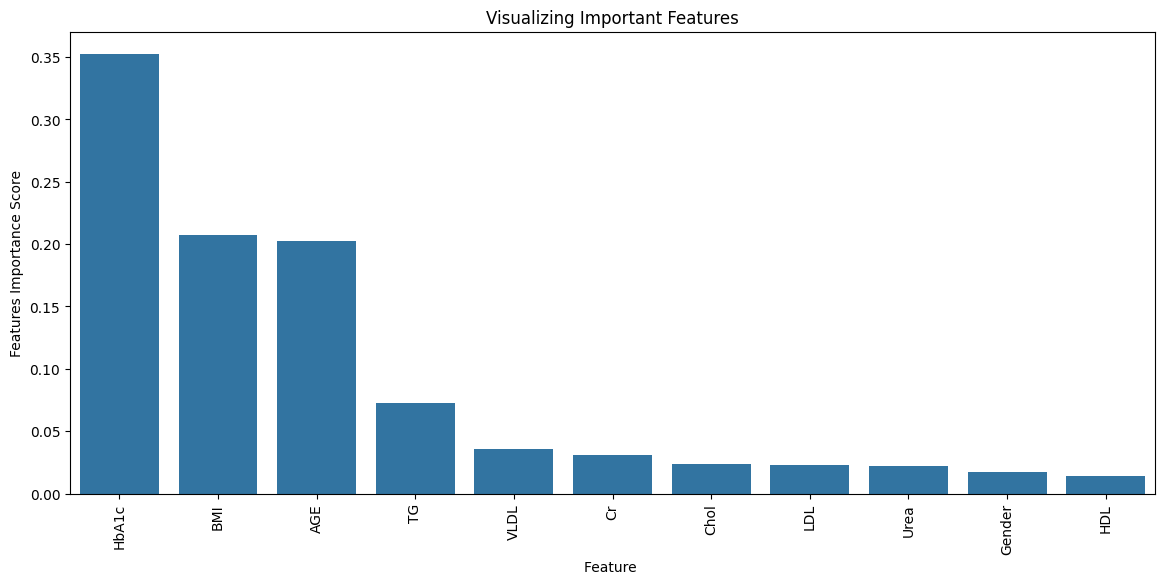

In [ ]:
#Sélection des meilleurs variables prédictrices à partir du modéle randomforest
plt.figure(figsize=(14,6))
vars_imp = pd.Series(rf.feature_importances_, index=train_feature.columns).sort_values(ascending=False)
sns.barplot(x = vars_imp.index, y = vars_imp)
plt.xticks(rotation=90)
plt.xlabel('Feature ')
plt.ylabel('Features Importance Score')
plt.title("Visualizing Important Features")
plt.show()

In [ ]:
vars_imp

,0
HbA1c,0.352629
BMI,0.207012
AGE,0.202384
TG,0.072328
VLDL,0.035383
Cr,0.030626
Chol,0.023884
LDL,0.022737
Urea,0.022062
Gender,0.017018


In [ ]:
#Selection
#vars_selected = vars_imp[vars_imp>0.001331].index.to_list()
vars_selected = vars_imp.index.to_list()
train_feature = train_feature[vars_selected]
X_val = X_val[vars_selected]
X_test = X_test[vars_selected]

In [ ]:
# Nombre de variable prédictrices
len(vars_selected)

11

**Entrainement des algorithmes**

1.   Notre objectif est de construire un modéle de classification qui prédit la classe diabéte d'un patient . Nous avons utiliser diffférents types d'algorithme à savoir (le Logistic Regression, Le Random Forest, Le Gradient Boosting, le Classificateur ou Perceptron Multicouche et le Support Vector Machine afin de  comparer leurs performances et de choisir le meilleur modéle .



. Modéle de regression logistique

In [ ]:
#Dictionnaire des hyperparamétres
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000] }
#Objet GridSearchCV
grid_logreg_class = GridSearchCV(estimator=LogisticRegression(random_state=seed, max_iter= 1000), param_grid= param_grid, cv=5, scoring='f1_macro')
#Entrainement de l'algorithme
logreg_model = grid_logreg_class.fit(train_feature, train_labels)
#Meilleur score et meilleur hyperparamétre
print(round(logreg_model.best_score_, 3))
print(logreg_model.best_estimator_)

0.984
LogisticRegression(C=1000, max_iter=1000, random_state=1111)


Le modéle a un bon score d'entrainement . Evaluons sa performance sur les données de validation afin d'aprécier sa  capacité à génaliser sur de nouvelle données.

In [ ]:
#Fonction d'évaluation de la performane d'un modéle
def model_evaluation(model, Features, labels):
  prediction = model.predict(Features)
  print(classification_report(labels, prediction))

In [ ]:
#Evaluation du modéle de regression logistique
model_evaluation(logreg_model, X_val, y_val)


              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       0.33      0.67      0.44         6
           2       0.99      0.92      0.95       124

    accuracy                           0.91       140
   macro avg       0.70      0.86      0.76       140
weighted avg       0.95      0.91      0.93       140



In [ ]:
# Création d'une fonction de construction d'un modéle avec utilisation de l'algorithme RFE
def model_with_rfe(model):
  rfe_model = RFE(estimator=model,verbose= 0)
  rfe_model.fit(train_feature, train_labels)
  mask= rfe_model.support_
  reduce_X =train_feature.iloc[:, mask]
  print(reduce_X.columns)
  return rfe_model

In [ ]:
# Logistic Régression avec RFE
rfe_logreg_model = model_with_rfe(logreg_model.best_estimator_)

Index(['HbA1c', 'BMI', 'TG', 'Chol', 'HDL'], dtype='object')


In [ ]:
#Evaluation du modéle de regression logistique aec RFE
model_evaluation(rfe_logreg_model, X_val, y_val)

              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.31      0.67      0.42         6
           2       0.99      0.92      0.95       124

    accuracy                           0.91       140
   macro avg       0.68      0.83      0.73       140
weighted avg       0.94      0.91      0.92       140



Conclusion:

---



La RFE qui fait la séléction recursif automatique a réduit le nbre de variable prédictif de 11 à 5 et n'a pas améliorer la performance du modéle. Mais garde les mémes performance avec le model avec 6 variable

**Algorithme RandoomForest**

In [ ]:
#Dictionnaire des hyperparamétres
param_grid_rf = {'n_estimators':[10,50,100,500,1000], 'max_depth':[3,5,10,20,None]}

#Objet GridSearchCV
grid_rf_class = GridSearchCV(estimator=RandomForestClassifier(random_state=seed), param_grid= param_grid_rf, cv=5, scoring='f1_macro')
#Entrainement de l'algorithme
rf_model = grid_rf_class.fit(train_feature, train_labels)
#Meilleur score et meilleur hyperparamétre
print(round(rf_model.best_score_, 3))
print(rf_model.best_estimator_)

0.998
RandomForestClassifier(max_depth=10, n_estimators=500, random_state=1111)


In [ ]:
#Evaluation du modéle de foret aléatoire
model_evaluation(rf_model.best_estimator_, X_val, y_val)

              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       1.00      0.67      0.80         6
           2       0.96      0.98      0.97       124

    accuracy                           0.95       140
   macro avg       0.91      0.78      0.84       140
weighted avg       0.95      0.95      0.95       140



In [ ]:
# Random Forest avec RFEE
rfe_forest_model = model_with_rfe(rf_model.best_estimator_)
rfe_forest_model

Index(['HbA1c', 'BMI', 'AGE', 'TG', 'Cr'], dtype='object')


RFE(estimator=RandomForestClassifier(max_depth=10, n_estimators=500,
                                     random_state=1111))

In [ ]:
#Evaluation du modéle de foret aléatoire avec RFE
model_evaluation(rfe_forest_model, X_val, y_val)

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       1.00      0.67      0.80         6
           2       0.96      0.99      0.98       124

    accuracy                           0.96       140
   macro avg       0.95      0.79      0.85       140
weighted avg       0.96      0.96      0.95       140



Conclusion:

---



La RFE  qui fait la séléction recursif automatique a réduit le nbre de variable prédictif qui devient 3 l'utilisant avec randomForest nous a permit d'avoir des résultat de F1-Score plus important que les autres.

**Classificateur Perceptron multicouche**

In [ ]:
#Classificateur Perceptron multicouche
#MLPClassifier
#Dictionnaire des hyperparamétres
mlp = MLPClassifier(random_state=seed, max_iter=1000)

parameters = {'hidden_layer_sizes': [(50,), (100,),(200,)],
              'activation': ['identity','relu', 'tanh', 'logistic'],
              'learning_rate': ['constant','invscaling', 'adaptive'],
              'solver': ['sgd', 'adam']}
#Objet GridSearchCV
mlp_cv = GridSearchCV(estimator=mlp, param_grid=parameters, cv=5, scoring='f1_macro', n_jobs= -1)
#Entrainement de l'algorithme
mlp_cv.fit(train_feature, train_labels)
#Meilleur score et meilleur hyperparamétre
print(round(mlp_cv.best_score_, 3))
print(mlp_cv.best_estimator_)

0.99
MLPClassifier(max_iter=1000, random_state=1111)


In [ ]:
#Evaluation du modéle de Perceptron multicouche avec RFE
model_evaluation(mlp_cv.best_estimator_ , X_val, y_val)

**Support vecteur machine**

In [ ]:
#Support vecteur machine
#Dictionnaire des hyperparamétres
svm_model = SVC(random_state=seed)
svm_hyp ={'kernel':['linear', 'rbf'], 'gamma':[0.01, 0.1, 1, 10, 100]}
#Objet GridSearchCV
svm_cv = GridSearchCV(svm_model,svm_hyp, cv=5, scoring='f1_macro')
#Entrainement de l'algorithme
svm_cv.fit(train_feature, train_labels)
#Meilleur score et meilleur hyperparamétre
print(round(svm_cv.best_score_, 3))
print(svm_cv.best_estimator_)

1.0
SVC(gamma=100, random_state=1111)


In [ ]:
#Evaluation du modéle de Support vecteur machine
model_evaluation(svm_cv.best_estimator_, X_val, y_val)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       1.00      0.17      0.29         6
           2       0.89      1.00      0.94       124

    accuracy                           0.89       140
   macro avg       0.63      0.39      0.41       140
weighted avg       0.83      0.89      0.85       140



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Conclusion:**

---



1.   Nous avons utilisées les données d'évaluation pour sélectionner le meilleur modéle . Ensuite nous évaluons le meilleur modéle sélectionné sur les données de test afin afin d'aprécier sa performance sur de nouvelles données. Idéalement les performances de ce modéle sur les données d'évaluation et sur les données de test doivent étre relativement proches.

Nous avons remarqué que l'algorithme randomForest sans RFE donnent les meilleurs citére de performance


In [ ]:
#Performance du meilleur modéle sur les données de test AVEC randomForest
model_evaluation(rf_model.best_estimator_, X_test, y_test)

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       1.00      1.00      1.00         5
           2       0.98      0.99      0.99       125

    accuracy                           0.98       141
   macro avg       0.96      0.94      0.95       141
weighted avg       0.98      0.98      0.98       141



<Axes: >

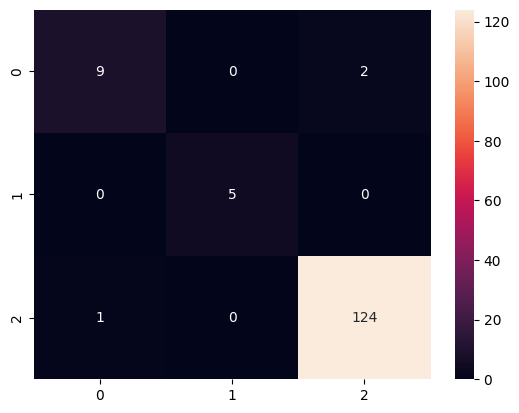

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, rf_model.best_estimator_.predict(X_test))
sns.heatmap(cm,annot=True,fmt='d')

In [ ]:
import joblib
joblib.dump(value=rf_model.best_estimator_,filename='rf_model.best_estimator.pkl')

['rf_model.best_estimator.pkl']